### Classification of images to following:

- cat
- dog
- wildlife(fox, tiger, lion and etc.)

In [3]:
# !pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Skipping, found downloaded files in ".\animal-faces" (use force=True to force download)


#### Needed Libraries

In [5]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [16]:
image_path = []
labels = []

for i in os.listdir('animal-faces\\afhq'):
    for label in os.listdir(f'animal-faces\\afhq\{i}'):
        for image in os.listdir(f'animal-faces\\afhq\{i}/{label}'):
            image_path.append(f'animal-faces\\afhq\{i}\{label}\{image}')
            labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns=['image_path', 'labels'])

print(data_df['labels'].value_counts())
data_df.head()

labels
cat     5653
dog     5239
wild    5238
Name: count, dtype: int64


<string>:5: SyntaxWarning: invalid escape sequence '\{'
<string>:6: SyntaxWarning: invalid escape sequence '\{'
<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:7: SyntaxWarning: invalid escape sequence '\{'
<>:5: SyntaxWarning: invalid escape sequence '\{'
<>:6: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:5: SyntaxWarning: invalid escape sequence '\{'
<string>:6: SyntaxWarning: invalid escape sequence '\{'
<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:7: SyntaxWarning: invalid escape sequence '\{'
<>:5: SyntaxWarning: invalid escape sequence '\{'
<>:6: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarning: invalid escape sequ

,image_path,labels
0,animal-faces\afhq\train\cat\flickr_cat_000002.jpg,cat
1,animal-faces\afhq\train\cat\flickr_cat_000003.jpg,cat
2,animal-faces\afhq\train\cat\flickr_cat_000004.jpg,cat
3,animal-faces\afhq\train\cat\flickr_cat_000005.jpg,cat
4,animal-faces\afhq\train\cat\flickr_cat_000006.jpg,cat


In [17]:
train = data_df.sample(frac=0.7)
test = data_df.drop(train.index)

val = test.sample(frac=0.5)
test = test.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)


(11291, 2)
(2420, 2)
(2419, 2)


In [66]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df['labels'])

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])  



In [67]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.Tensor(label_encoder.transform(self.dataframe['labels'])).to(device) 

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image).to(device)

        return image, label       

In [68]:
train_dataset = CustomImageDataset(dataframe=train, transform=trainsform)
val_dataset = CustomImageDataset(dataframe=val, transform=trainsform)
test_dataset = CustomImageDataset(dataframe=test, transform=trainsform)

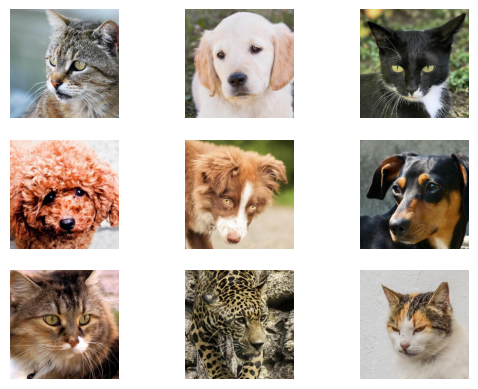

In [69]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
    for col in range(n_cols):
        image = Image.open(data_df.sample(n = 1)['image_path'].iloc[0]).convert('RGB')
        axarr[row, col].imshow(image)
        axarr[row, col].axis('off')

plt.show()


In [70]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [71]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [72]:
class Net(nn.Module):
    def __init__(self):
      super().__init__()

      self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding = 1) # First Convolution layer
      self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1) # Second Convolution layer
      self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1) # Third Convolution layer
      self.pooling = nn.MaxPool2d(2,2) # The pooling layer, we will be using the same layer after each conv2d.
      self.relu = nn.ReLU() # ReLU Activation function

      self.flatten = nn.Flatten() # Flatten and vectorize the output feature maps that somes from the final convolution layer.
      self.linear = nn.Linear((128 * 16 * 16), 128) # Traditional Dense (Linear)
      self.output = nn.Linear(128, len(data_df['labels'].unique())) # Output Linear Layer


    def forward(self, x):
      x = self.conv1(x) # -> Outputs: (32, 128, 128)
      x = self.pooling(x)# -> Outputs: (32, 64, 64)
      x = self.relu(x)
      x = self.conv2(x) # -> Outputs: (64, 64, 64)
      x = self.pooling(x) # -> Outputs: (64, 32, 32)
      x = self.relu(x)
      x = self.conv3(x) # -> Outputs: (128, 32, 32)
      x = self.pooling(x) # -> Outputs: (128, 16, 16)
      x = self.relu(x)
      x = self.flatten(x)
      x = self.linear(x)
      x = self.output(x)

      return x

model = Net().to(device) # Create an instance of the model and move it to the GPU Device

### Training the Model

In [73]:
from torchsummary import summary
summary(model, (3, 128, 128))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [74]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)


In [75]:
total_loss_train_plot = []
total_loss_val_plot = []

total_acc_train_plot = []
total_acc_val_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_acc_val = 0
    total_loss_train = 0
    total_loss_val = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device).long()
        optimizer.zero_grad()
        
        outputs = model(inputs)
        train_loss = criterion(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()

        total_acc_train += (torch.argmax(outputs, axis=1) == labels).sum().item()
        
        optimizer.step()

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).long()

            outputs = model(inputs)
            val_loss = criterion(outputs, labels)
            total_loss_val += val_loss.item()

            total_acc_val += (torch.argmax(outputs, axis=1) == labels).sum().item()

    total_loss_train_plot.append(round(total_loss_train / 1000, 4))
    total_loss_val_plot.append(round(total_loss_val / 1000, 4))
    total_acc_train_plot.append(round(total_acc_train / train_dataset.__len__() *100, 4))
    total_acc_val_plot.append(round(total_acc_val / val_dataset.__len__() *100, 4))

    print()
    print(f"Epoch: {epoch + 1}")
    print(f"Train Loss: {total_loss_train_plot[-1]}")
    print(f"Train Accuracy: {total_acc_train_plot[-1]}")
    print(f"Val Loss: {total_loss_val_plot[-1]}")
    print(f"Val Accuracy: {total_acc_val_plot[-1]}")



Epoch: 1
Train Loss: 0.3304
Train Accuracy: 80.1523
Val Loss: 0.0353
Val Accuracy: 91.2397

Epoch: 2
Train Loss: 0.132
Train Accuracy: 93.1893
Val Loss: 0.0237
Val Accuracy: 94.0083

Epoch: 3
Train Loss: 0.0886
Train Accuracy: 95.5186
Val Loss: 0.0262
Val Accuracy: 93.6777

Epoch: 4
Train Loss: 0.0687
Train Accuracy: 96.4928
Val Loss: 0.0215
Val Accuracy: 95.2893

Epoch: 5
Train Loss: 0.0447
Train Accuracy: 97.6707
Val Loss: 0.0193
Val Accuracy: 95.8264

Epoch: 6
Train Loss: 0.0335
Train Accuracy: 98.3438
Val Loss: 0.019
Val Accuracy: 95.9917

Epoch: 7
Train Loss: 0.0249
Train Accuracy: 98.8132
Val Loss: 0.0187
Val Accuracy: 96.0331

Epoch: 8
Train Loss: 0.0191
Train Accuracy: 99.0966
Val Loss: 0.0195
Val Accuracy: 96.281

Epoch: 9
Train Loss: 0.0131
Train Accuracy: 99.3978
Val Loss: 0.0227
Val Accuracy: 95.8678

Epoch: 10
Train Loss: 0.0111
Train Accuracy: 99.4509
Val Loss: 0.0264
Val Accuracy: 95.1653


In [76]:

with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0 
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device).long()

        outputs = model(inputs)
        test_loss = criterion(outputs, labels)
        total_loss_test += test_loss.item()

        total_acc_test += (torch.argmax(outputs, axis=1) == labels).sum().item()

print(f"Test Loss: {total_loss_test / 1000}")
print(f"Test Accuracy: {total_acc_test / test_dataset.__len__() *100}")

Test Loss: 0.024806761063517115
Test Accuracy: 95.57668458040513


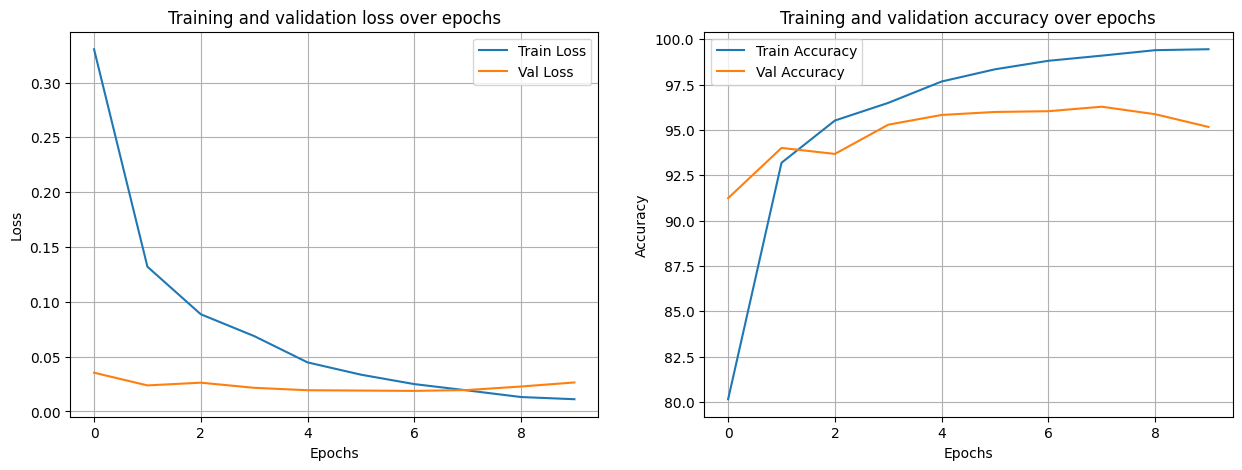

In [80]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Train Loss')
axs[0].plot(total_loss_val_plot, label='Val Loss')
axs[0].set_title('Training and validation loss over epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid()

axs[1].plot(total_acc_train_plot, label='Train Accuracy')
axs[1].plot(total_acc_val_plot, label='Val Accuracy')
axs[1].set_title('Training and validation accuracy over epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid()

plt.show()

In [95]:
# 1. - Read the image
# 2. - transform using transform object
# 3. - predict through model
# 4. - inverse transform by label encoder 

def predict_image(img_path):
    image = Image.open(img_path).convert('RGB')
    image = transform(image).to(device)
    
    output = model(image.unsqueeze(0))
    output = torch.argmax(output, axis=1).item()
    return label_encoder.inverse_transform([output])

In [96]:
img_path = 'animal-faces/afhq/silver-tabby-cat-sitting-on-green-background-free-photo.jpg'
predict_image(img_path=img_path)

array(['wild'], dtype=object)